# Imports

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import glob
import os

folder_path = "/content/drive/MyDrive/trackman/"

df = pd.read_csv("/content/drive/MyDrive/trackman/full_combined_dataset.csv")

print(df["BatterTeam"].unique())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipykernel_735/3178253330.py:10: DtypeWarning: Columns (27,92,93,167,182,184,186,188,190,192,194,196) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/drive/MyDrive/trackman/full_combined_dataset.csv")


['BAB_COL' 'TUF_UNI' 'BOW_COL' 'JOH_AND' 'END_COL' 'EAS_NAZ' 'AMH_COL'
 'BRA_UNI' 'EAS_CON' 'MAS_INS' 'UMA_BOS' 'WHE_C' 'BAT_COL' 'COL_COL10'
 'TRI_COL1' 'CLA_UNI' 'WOR_POL' 'HAM_COL1' 'ARI_CHR' 'SOU_UNI' 'UNI_BRI'
 'TEN_WES' 'LEW_STA' 'UNI_COL' 'LIM_STO' 'EMB_EAG' 'UNI_MON' 'UNI_PIK'
 'WIL_CAR' 'LIN_MEM' 'NOR_GEO3' 'LOS_ANG1' 'CYP_CHR' 'HOP_INT' 'NOR_OKL'
 'PAN_COL' 'EC' 'LEE_UNI' 'CAL_COM' 'CLE_CLE2' 'SOU_COM' 'IOW_CEN'
 'LIN_WIL1' 'REI_UNI' 'MSA_M' 'ANG_COL' 'ALV_CCO' 'MON_MUS' 'SAN_JAC'
 'GAL_WCS' 'LAN_BEA' 'BRY_COL' 'STU_BOB' 'SAN_DIE23' 'Gol_W' 'OKL_WES'
 'AVE_MAR' 'UNI_SAI1' 'LEN_BEA' 'YOU_HAR' 'TAM_SPA' 'COL_CUG' 'AUB_UNI'
 'SOU_WES1' 'WAB_VAL2' 'WAB_WAB' 'NMX_THU' 'SEM_STA1' 'Mer_Col' 'ANG_STA'
 'UNI_TEX' 'EAS_OKL' 'EAS_TEX' 'POM_COL' 'PAL_COM' 'IlI_SPR' 'TUS_PIO'
 'SAN_FRA3' 'WES_COL' 'MID_UNI' 'AND_TRO' 'RHO_COL' 'FUL_COL' 'LON_BEA'
 'CUY_CUY' 'WAB_VAL' 'SEM_STA' 'EMO_HEN' 'ORA_COA' 'YAN_YAN' 'BAR_COM'
 'MAR_LIO' 'TNU' 'CAR_EAG' 'CHA_GOL' 'KIN_UNI' 'WES_UNI' 'CHA_UNI'
 'GEO_

# Pitch movement (smaller group)

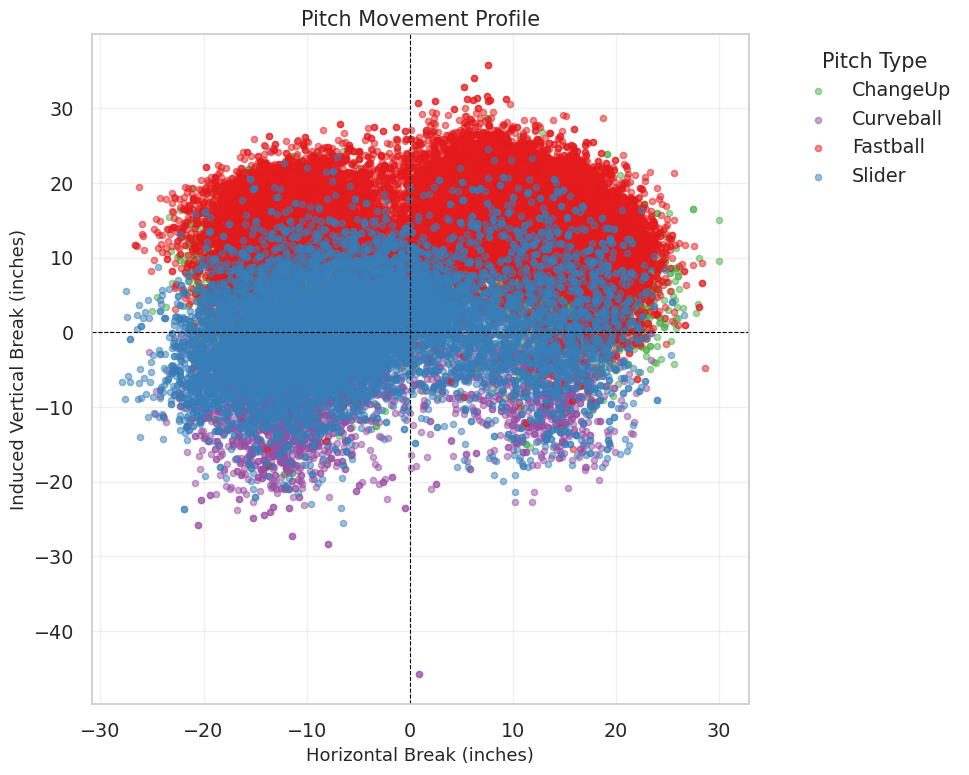

In [ ]:
import matplotlib.pyplot as plt

# Filter to common pitch types only
common_pitches = ["Fastball", "Slider", "ChangeUp", "Curveball"]

plot_df = df[df["TaggedPitchType"].isin(common_pitches)].dropna(subset=["InducedVertBreak", "HorzBreak"])

plot_df["TaggedPitchType"].unique()

# Fixed color map per pitch type
color_map = {
    "Fastball":  "#E41A1C",
    "Slider":    "#377EB8",
    "ChangeUp":  "#4DAF4A",
    "Curveball": "#984EA3",
    "Cutter":    "#FF7F00",
    "Sinker":    "#A65628"
}

fig, ax = plt.subplots(figsize=(10, 8))

for pitch, group in plot_df.groupby("TaggedPitchType"):
    ax.scatter(
        group["HorzBreak"],
        group["InducedVertBreak"],
        label=pitch,
        color=color_map[pitch],
        alpha=0.5,
        s=20
    )

ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")

ax.set_xlabel("Horizontal Break (inches)", fontsize=13)
ax.set_ylabel("Induced Vertical Break (inches)", fontsize=13)
ax.set_title("Pitch Movement Profile", fontsize=15)
ax.legend(title="Pitch Type", bbox_to_anchor=(1.05, 1), loc="upper left")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
plot_df["TaggedPitchType"].unique()


array(['Fastball', 'Slider', 'ChangeUp', 'Curveball'], dtype=object)

# Tufts pitch movement profile

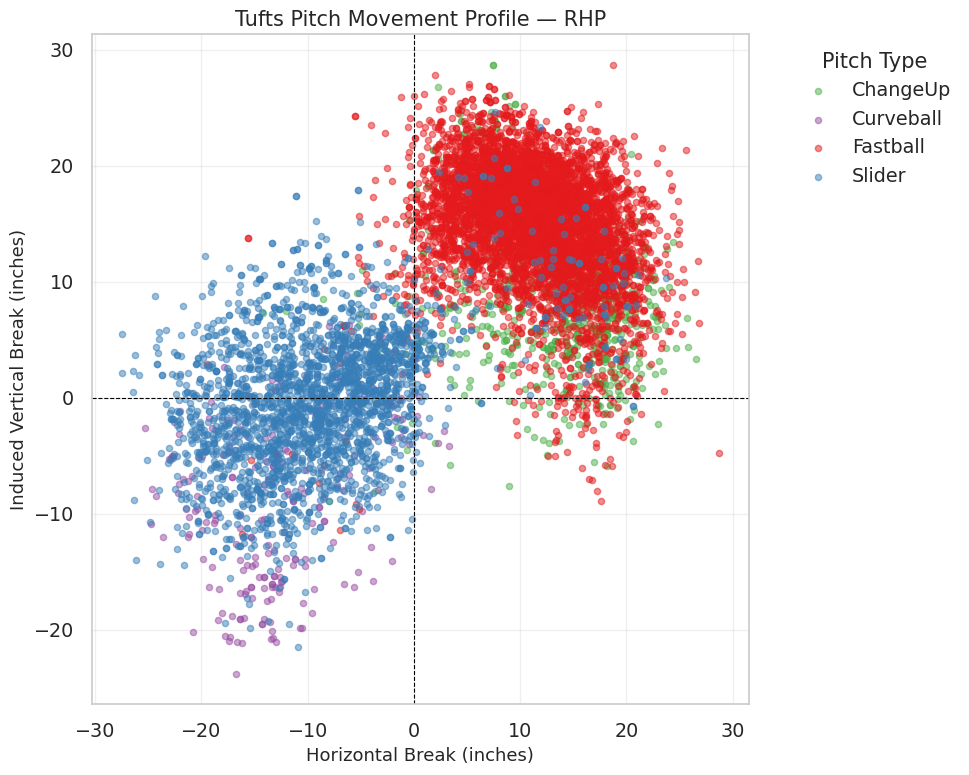

Total pitches plotted: 9202


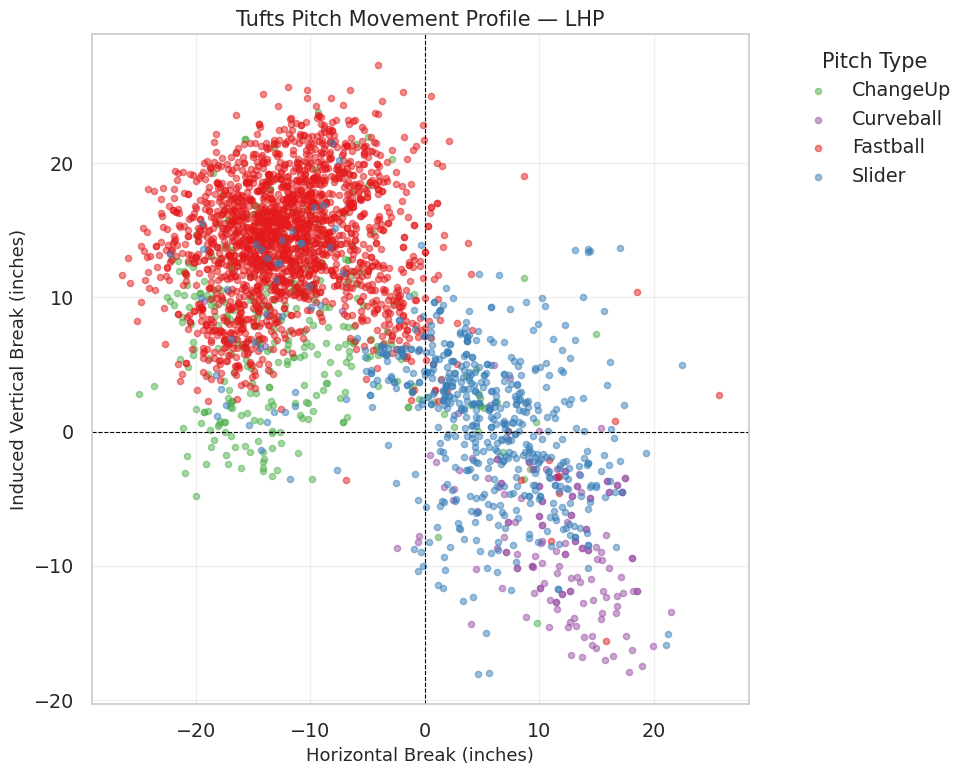

Total pitches plotted: 3048


In [ ]:
import matplotlib.pyplot as plt

# Filter to Tufts involvement
tufts_df = df[
    (df["BatterTeam"] == "TUF_UNI") | (df["PitcherTeam"] == "TUF_UNI")
]
l_df = tufts_df[tufts_df["PitcherThrows"].isin(["L", "Left"])]
r_df = tufts_df[tufts_df["PitcherThrows"].isin(["R", "Right"])]

common_pitches = ["Fastball", "Slider", "ChangeUp", "Curveball"]

# Fixed color map
color_map = {
    "Fastball":  "#E41A1C",
    "Slider":    "#377EB8",
    "ChangeUp":  "#4DAF4A",
    "Curveball": "#984EA3",
    "Cutter":    "#FF7F00",
    "Sinker":    "#A65628"
}

def plot_movement(df, title):
    plot_df = df[df["TaggedPitchType"].isin(common_pitches)].copy()
    plot_df["InducedVertBreak"] = pd.to_numeric(plot_df["InducedVertBreak"], errors="coerce")
    plot_df["HorzBreak"] = pd.to_numeric(plot_df["HorzBreak"], errors="coerce")
    plot_df = plot_df.dropna(subset=["InducedVertBreak", "HorzBreak"])

    fig, ax = plt.subplots(figsize=(10, 8))
    for pitch, group in plot_df.groupby("TaggedPitchType"):
        ax.scatter(
            group["HorzBreak"],
            group["InducedVertBreak"],
            label=pitch,
            color=color_map[pitch],
            alpha=0.5,
            s=20
        )
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_xlabel("Horizontal Break (inches)", fontsize=13)
    ax.set_ylabel("Induced Vertical Break (inches)", fontsize=13)
    ax.set_title(title, fontsize=15)
    ax.legend(title="Pitch Type", bbox_to_anchor=(1.05, 1), loc="upper left")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    print(f"Total pitches plotted: {len(plot_df)}")

plot_movement(r_df, "Tufts Pitch Movement Profile — RHP")
plot_movement(l_df, "Tufts Pitch Movement Profile — LHP")

# Running PCA

In [ ]:
import numpy as np
import sklearn.datasets
import sklearn.decomposition
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8') # pretty matplotlib plots

import seaborn as sns
sns.set('notebook', font_scale=1.25, style='whitegrid')

import matplotlib.colors as mcolors

from sklearn.cluster import KMeans

          RelSpeed     SpinRate  InducedVertBreak  HorzBreak  RelHeight  \
Cluster                                                                   
0        80.719101  1807.269329          8.808127  13.993204   5.195829   
1        78.521225  2278.263046          2.372024  10.907196   5.706081   
2        82.172607  2031.862904         12.494251 -10.309252   5.803120   
3        87.288315  2182.761156         17.037379  10.822873   5.905468   
4        75.601905  2335.557520         -2.582407 -10.807909   5.606235   

         Extension    SpinAxis  
Cluster                         
0         6.120253  240.624231  
1         5.302450  263.408473  
2         6.027220  137.017966  
3         6.012673  213.899068  
4         5.359674   71.502221  


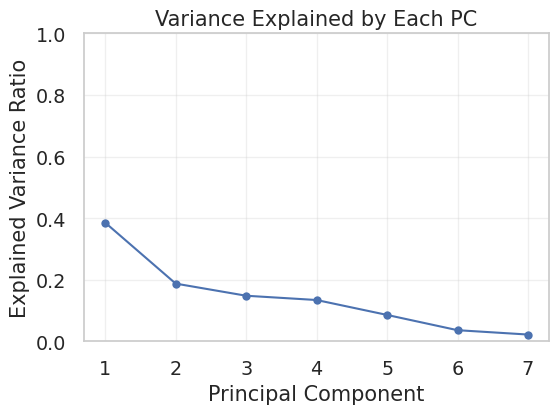

In [ ]:
# Filter pitch types
common_pitches = ["Fastball", "Slider", "ChangeUp", "Curveball"]
plot_df = df[df["TaggedPitchType"].isin(common_pitches)].copy()

features = [
    "RelSpeed",
    "SpinRate",
    "InducedVertBreak",
    "HorzBreak",
    "RelHeight",
    "Extension",
    "SpinAxis"
]

plot_df = plot_df.dropna(subset=features).copy()

# Mirror lefties
left_mask = plot_df["PitcherThrows"] == "L"
plot_df.loc[left_mask, "HorzBreak"] *= -1
plot_df.loc[left_mask, "SpinAxis"] = (360 - plot_df.loc[left_mask, "SpinAxis"]) % 360

# PCA
X = plot_df[features].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
Z = pca.fit_transform(X_scaled)

# Clustering
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(Z[:, :3])
plot_df["Cluster"] = clusters

# Cluster interpretation
cluster_summary = plot_df.groupby("Cluster")[features].mean()
print(cluster_summary)

explained = pca.explained_variance_ratio_
pcs = np.arange(1, len(explained) + 1)

plt.figure(figsize=(6,4))
plt.plot(pcs, explained, marker='o')
plt.xticks(pcs)
plt.ylim(0, 1)
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Variance Explained by Each PC")
plt.grid(alpha=0.3)
plt.show()


In [ ]:
pc_loadings = pd.DataFrame(
    pca.components_,
    columns=features,
    index=[f"PC{i+1}" for i in range(len(features))]
)

print(pc_loadings)


     RelSpeed  SpinRate  InducedVertBreak  HorzBreak  RelHeight  Extension  \
PC1  0.447915 -0.167505          0.464589   0.478278   0.043096   0.296716   
PC2  0.414656  0.420679          0.334733  -0.315400   0.579672   0.036059   
PC3 -0.035633 -0.504554          0.210237  -0.390418  -0.165740   0.639581   
PC4 -0.250636 -0.627956          0.077581   0.011653   0.654108  -0.322840   
PC5 -0.308813  0.239976         -0.429135   0.159409   0.450374   0.629397   
PC6  0.654995 -0.295095         -0.637742   0.138580   0.061371  -0.007400   
PC7 -0.197382  0.037402          0.176126   0.688909   0.013918   0.034287   

     SpinAxis  
PC1  0.486646  
PC2 -0.319760  
PC3 -0.333161  
PC4  0.067941  
PC5  0.196217  
PC6 -0.232722  
PC7 -0.672797  


In [ ]:
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"PC{i+1}: {var:.4f}")


PC1: 0.3854
PC2: 0.1876
PC3: 0.1482
PC4: 0.1343
PC5: 0.0859
PC6: 0.0364
PC7: 0.0222


# PCA loadings heatmap

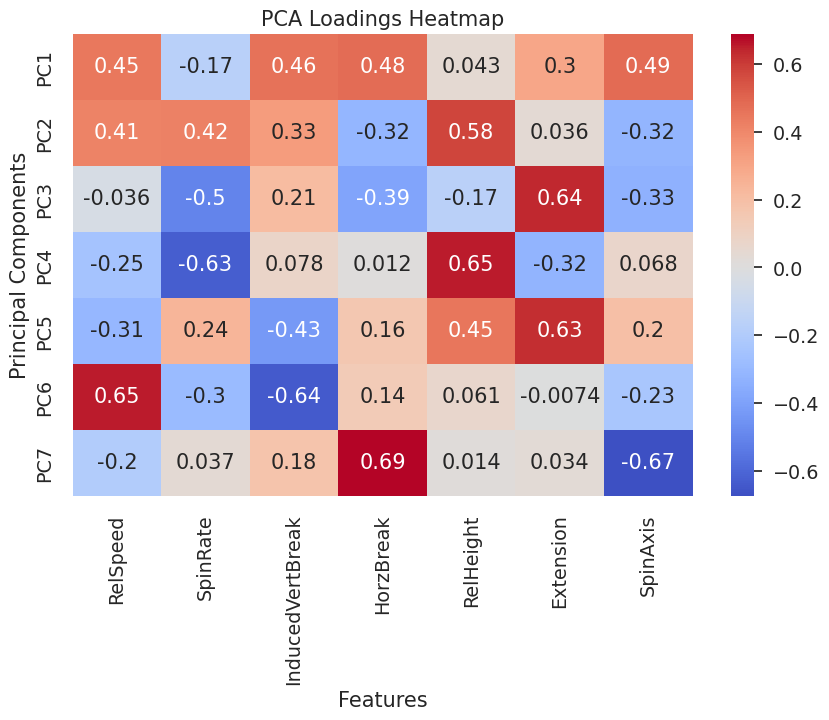

In [ ]:
import seaborn as sns
plt.figure(figsize=(10,6))
sns.heatmap(pc_loadings, annot=True, cmap="coolwarm", center=0)
plt.title("PCA Loadings Heatmap")
plt.xlabel("Features")
plt.ylabel("Principal Components")
plt.show()


In [ ]:
total = 0
for i in range(3):
  total += pca.explained_variance_ratio_[i]
print(total)

0.721207925239397


PC1 Expalins approx

In [ ]:
# Drop NA rows consistently
plot_df = plot_df.dropna(subset=features).copy()

# Extract features
X = plot_df[features].values

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = sklearn.decomposition.PCA()
Z = pca.fit_transform(X_scaled)

# Clustering
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(Z[:, :3])

# Assign clusters back to the SAME DataFrame
plot_df["Cluster"] = clusters

plot_df.groupby("Cluster")[features].mean()


,RelSpeed,SpinRate,InducedVertBreak,HorzBreak,RelHeight,Extension,SpinAxis
Cluster,,,,,,,
0,80.719101,1807.269329,8.808127,13.993204,5.195829,6.120253,240.624231
1,78.521225,2278.263046,2.372024,10.907196,5.706081,5.302450,263.408473
2,82.172607,2031.862904,12.494251,-10.309252,5.803120,6.027220,137.017966
3,87.288315,2182.761156,17.037379,10.822873,5.905468,6.012673,213.899068
4,75.601905,2335.557520,-2.582407,-10.807909,5.606235,5.359674,71.502221
